# ArbEPI demo

Generates the same four sequences as `main.py` (`ArbEPI`, `EPIcal`, `noise`, `deGRE`)
and shows the diagnostics along the way: the sampling mask and its point spread
function, the k-space trajectory of each shot, a single-TR pulse diagram, the PNS
over one TR, and the GE hardware/PNS/acoustics check that `main.py --ge` runs before
exporting.

Every parameter comes from `params.py`'s `load_params()`; edit its "USER
CONFIGURATION" section to change the protocol. Sequences are written to
`params.output_dir` (default `output/`, gitignored), exactly where `main.py` puts them.

To run it, from the repo root:

```
uv sync --extra test
uv run --with jupyter jupyter lab demo.ipynb
```

In [1]:
%env TQDM_DISABLE=1

env: TQDM_DISABLE=1


In [2]:
import dataclasses
import io
import os
import warnings

import hdf5storage
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

from ge.ge_export import check_ge_feasibility, export_to_ge
from params import load_params
from plotting.plotting import (
    nominal_te_value,
    plot_one_tr,
    plot_pns_one_tr,
    plot_psf,
    plot_sampling_mask,
    plot_trajectory,
)
from sampling.gen_sampling_masks import resolve_omegas
from sequences.ArbEPI import generate_arbepi
from sequences.deGRE import generate_degre
from sequences.EPIcal import generate_epical
from sequences.noise import generate_noise

# pypulseq raises the RF delay to the scanner's dead time on its own; nothing to act on.
warnings.filterwarnings("ignore", message="Specified RF delay")


def show(fig, width=None):
    # The plotting functions return figures with no pyplot manager, which Jupyter
    # won't render on its own, so render each one to PNG here.
    if width is not None:
        w, h = fig.get_size_inches()
        fig.set_size_inches(width, h * width / w)
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
    plt.close(fig)
    display(Image(buf.getvalue()))


def side_by_side(figs, titles, width=14):
    # Rasterize each figure and tile the images in one row.
    images = []
    for fig in figs:
        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
        plt.close(fig)
        buf.seek(0)
        images.append(plt.imread(buf))
    aspect = max(im.shape[0] / im.shape[1] for im in images)
    _, axes = plt.subplots(1, len(images), figsize=(width, width / len(images) * aspect))
    for ax, im, title in zip(axes, images, titles):
        ax.imshow(im)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## 1. Parameters

`load_params()` returns one `Params` dataclass that every generator takes. The
fields below are the ones in its "USER CONFIGURATION" section, plus a few that are
derived from them (`fov`, `Nframes`, `Nshots`, `TR`, flip angle).

In [3]:
params = load_params()

rows = {
    "scanner": params.spec.name,
    "res (mm)": params.res * 1e3,
    "N [Nx, Ny, Nz]": [params.Nx, params.Ny, params.Nz],
    "fov (mm)": params.fov * 1e3,
    "TE (ms)": params.TE * 1e3,
    "volume_tr (s)": params.volume_tr,
    "Nframes": params.Nframes,
    "ETL": params.ETL,
    "R": params.R,
    "Nshots per volume": params.Nshots,
    "TR per shot (ms)": params.TR * 1e3,
    "flip angle (deg)": params.fa,
    "sampling_method": params.sampling_method,
    "seed": params.seed,
    "epi_trajectory": params.epi_trajectory,
}
for k, v in rows.items():
    print(f"{k:>20}: {np.round(v, 3) if isinstance(v, (float, np.ndarray)) else v}")

             scanner: GE Discovery MR750 (XRM gradient coil)
            res (mm): [2.4 2.4 2.4]
      N [Nx, Ny, Nz]: [90, 90, 60]
            fov (mm): [216. 216. 144.]
             TE (ms): 30.0
       volume_tr (s): 1.0
             Nframes: 60
                 ETL: 60
                   R: 6
   Nshots per volume: 15
    TR per shot (ms): 66.667
    flip angle (deg): 18.193
     sampling_method: pd
                seed: 0
      epi_trajectory: radial


## 2. Sampling masks

`resolve_omegas` returns one boolean `(Ny, Nz)` mask per frame: from
`gen_sampling_masks` (`params.sampling_method`, `params.R`, `params.seed`), or your
own mask when `custom_mask_path` is set in `params.py` (see the README's "Using
custom ky-kz-t sampling masks"). Below: frame 1's mask, and its point spread
function, the aliasing the undersampling leaves in the y-z plane.

omegas: (90, 60, 60), 900 samples per frame = 15 shots x ETL 60


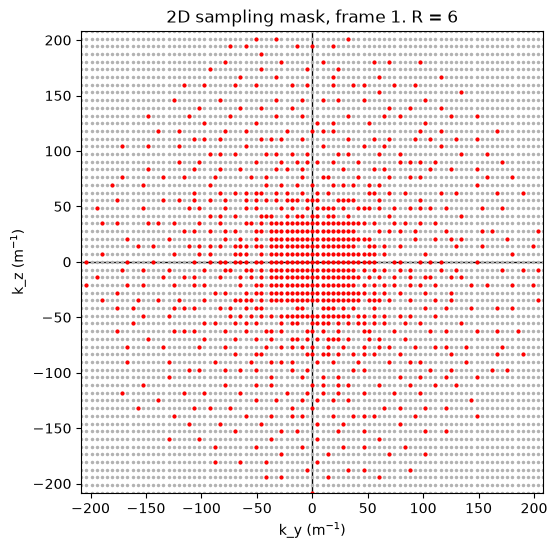

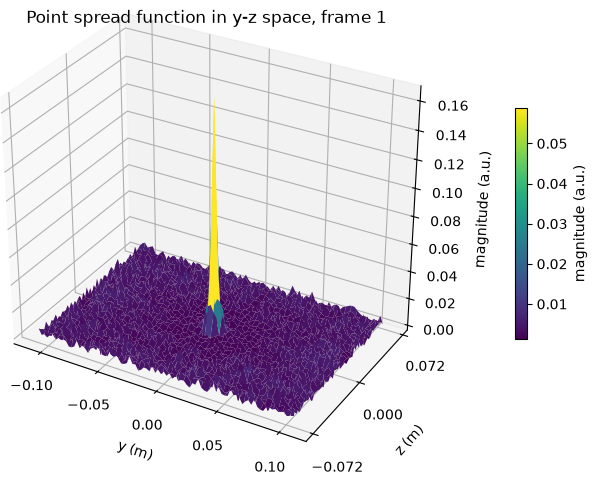

In [4]:
omegas = resolve_omegas(params)
print(f"omegas: {omegas.shape}, {omegas[..., 0].sum()} samples per frame "
      f"= {params.Nshots} shots x ETL {params.ETL}")

show(plot_sampling_mask(omegas, params, params.R), width=6)
show(plot_psf(omegas, params), width=10)

## 3. The ArbEPI sequence

`generate_arbepi` splits each frame's mask into `Nshots` echo trains of `ETL`
samples (`lib/mask2epi.py`, see the README's "Trajectory computation"), builds the
readout and blip gradients, and writes `ArbEPI.seq` plus `scan_info.mat`, which
holds the sampling schedule, the kx trajectories for ghost correction and the scan
parameters `preprocess/` needs.

In [5]:
seq = generate_arbepi(omegas, params)

info = hdf5storage.loadmat(os.path.join(params.output_dir, "scan_info.mat"))
schedules = info["schedules"]  # Nframes x Nshots x ETL x 3: 1-based (ky, kz), echo time (s)
echo_times = schedules[0, 0, :, 2]
print(f"schedules: {schedules.shape}")
print(f"echo spacing: {np.diff(echo_times).mean() * 1e3:.3f} ms, "
      f"realized TE: {nominal_te_value(echo_times, params.ETL) * 1e3:.2f} ms "
      f"(prescribed {params.TE * 1e3:.2f} ms)")

Selected ADC dwell: 4.0 us (fastest feasible for Nx=90, fov_x=216.0 mm -- see lib/readout_from_params.py's find_min_feasible_dwell)


Timing check passed successfully


schedules: (60, 15, 60, 3)
echo spacing: 0.696 ms, realized TE: 30.00 ms (prescribed 30.00 ms)


### Trajectory: `radial` vs. `laminar`

`params.epi_trajectory` selects how `mask2epi_*` turns a mask into echo trains:
`'radial'` (the default) makes every shot a spoke through k-space center, and
`'laminar'` fills ky-non-decreasing rows. To compare them, the cell below builds a
second ArbEPI sequence from the same masks with the other ordering, into its own
subdirectory (`output/laminar/` at the defaults) so it doesn't overwrite the files above. Each color is one shot; the
black-edged dot marks where its echo train starts.

Selected ADC dwell: 4.0 us (fastest feasible for Nx=90, fov_x=216.0 mm -- see lib/readout_from_params.py's find_min_feasible_dwell)


Timing check passed successfully


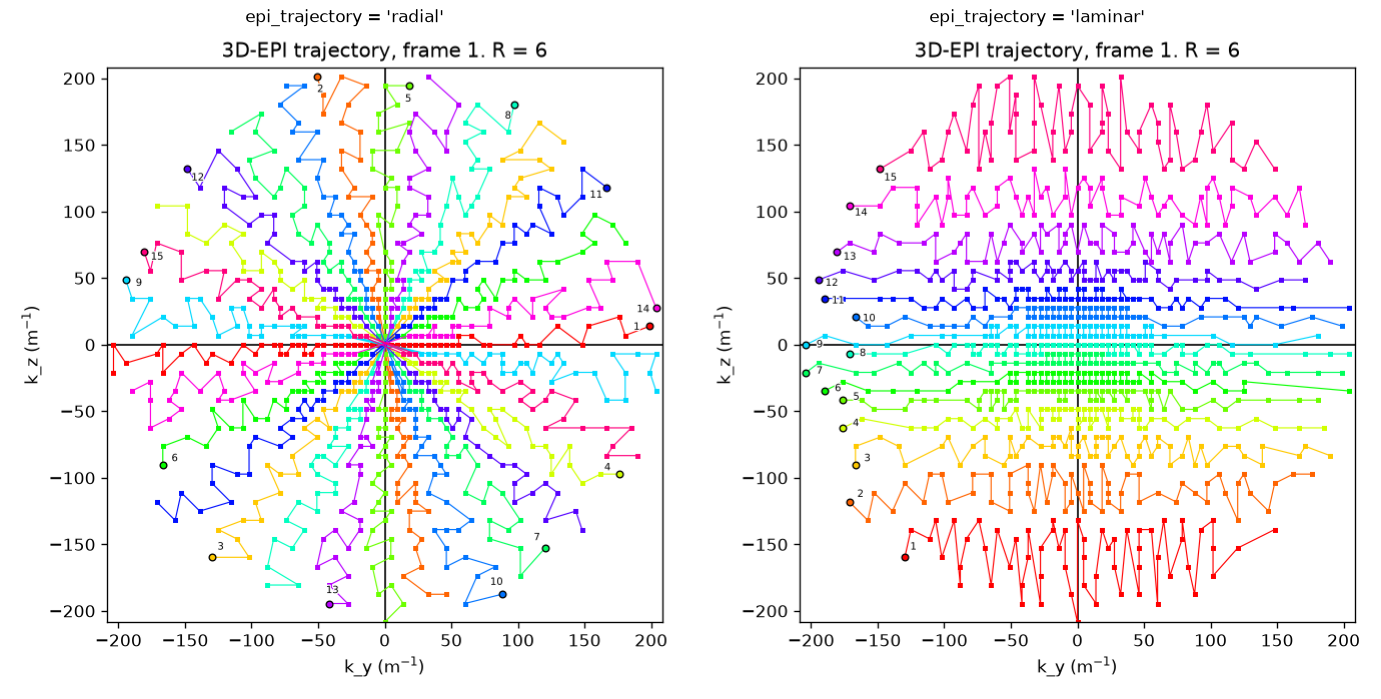

In [6]:
other = "laminar" if params.epi_trajectory == "radial" else "radial"
params_other = dataclasses.replace(
    params, epi_trajectory=other, output_dir=os.path.join(params.output_dir, other)
)
seq_other = generate_arbepi(omegas, params_other)

side_by_side(
    [plot_trajectory(seq, params, params.R, frame_idx=0),
     plot_trajectory(seq_other, params_other, params.R, frame_idx=0)],
    [f"epi_trajectory = '{params.epi_trajectory}'", f"epi_trajectory = '{other}'"],
)

### One TR

The first shot of frame 1 (fat saturation, RF-spoiled excitation, the EPI readout,
spoilers), drawn by pypulseq's own `Sequence.plot()`; the dashed line marks TE.
Each small Gy/Gz pulse in the readout is a blip, the step from one (ky, kz) sample
to the next, so the blip pattern is where the two orderings differ.

epi_trajectory = 'radial'


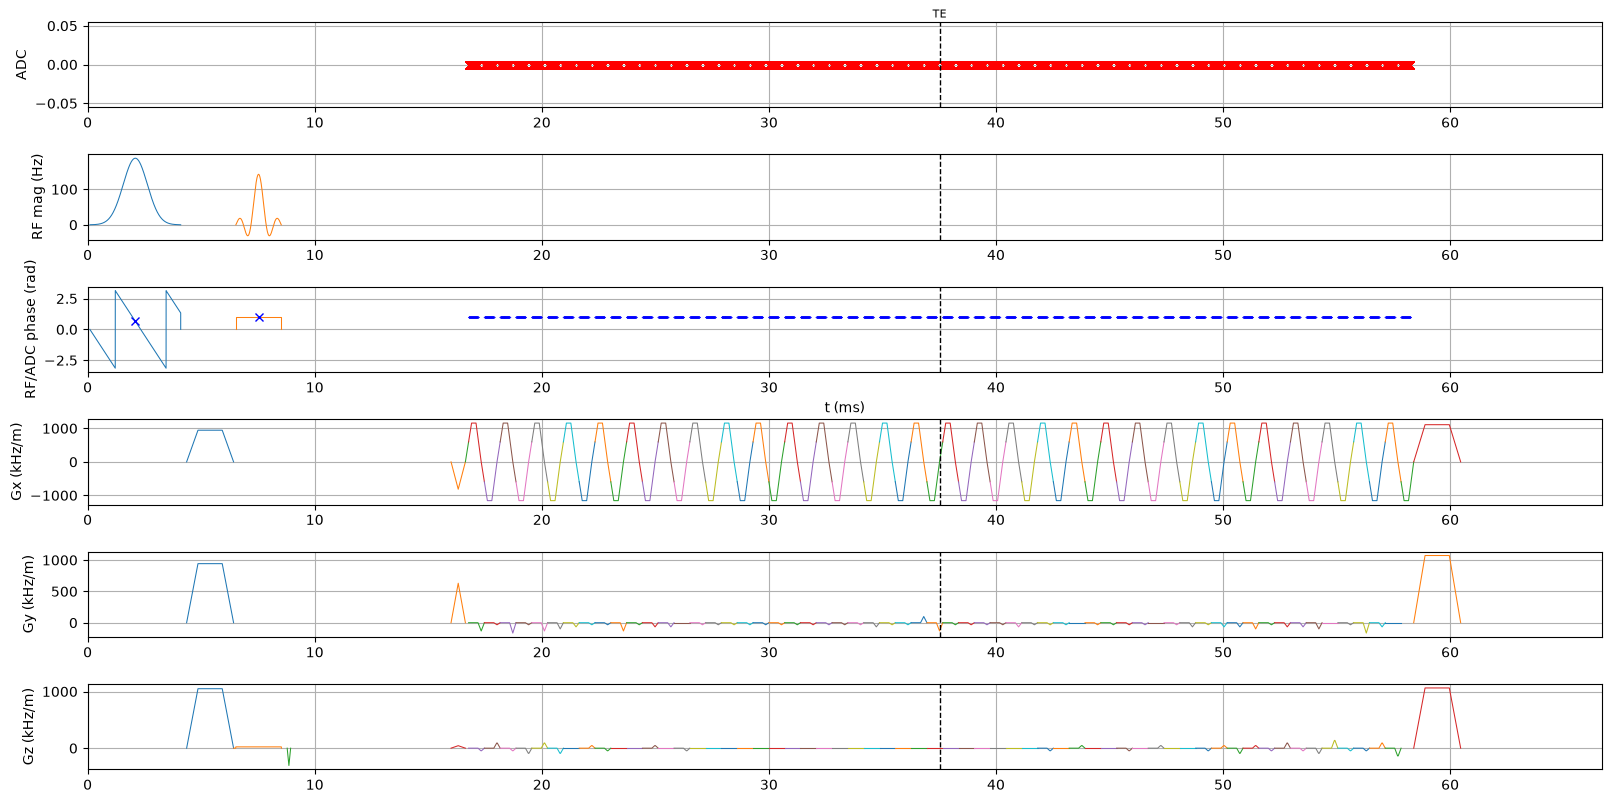

epi_trajectory = 'laminar'


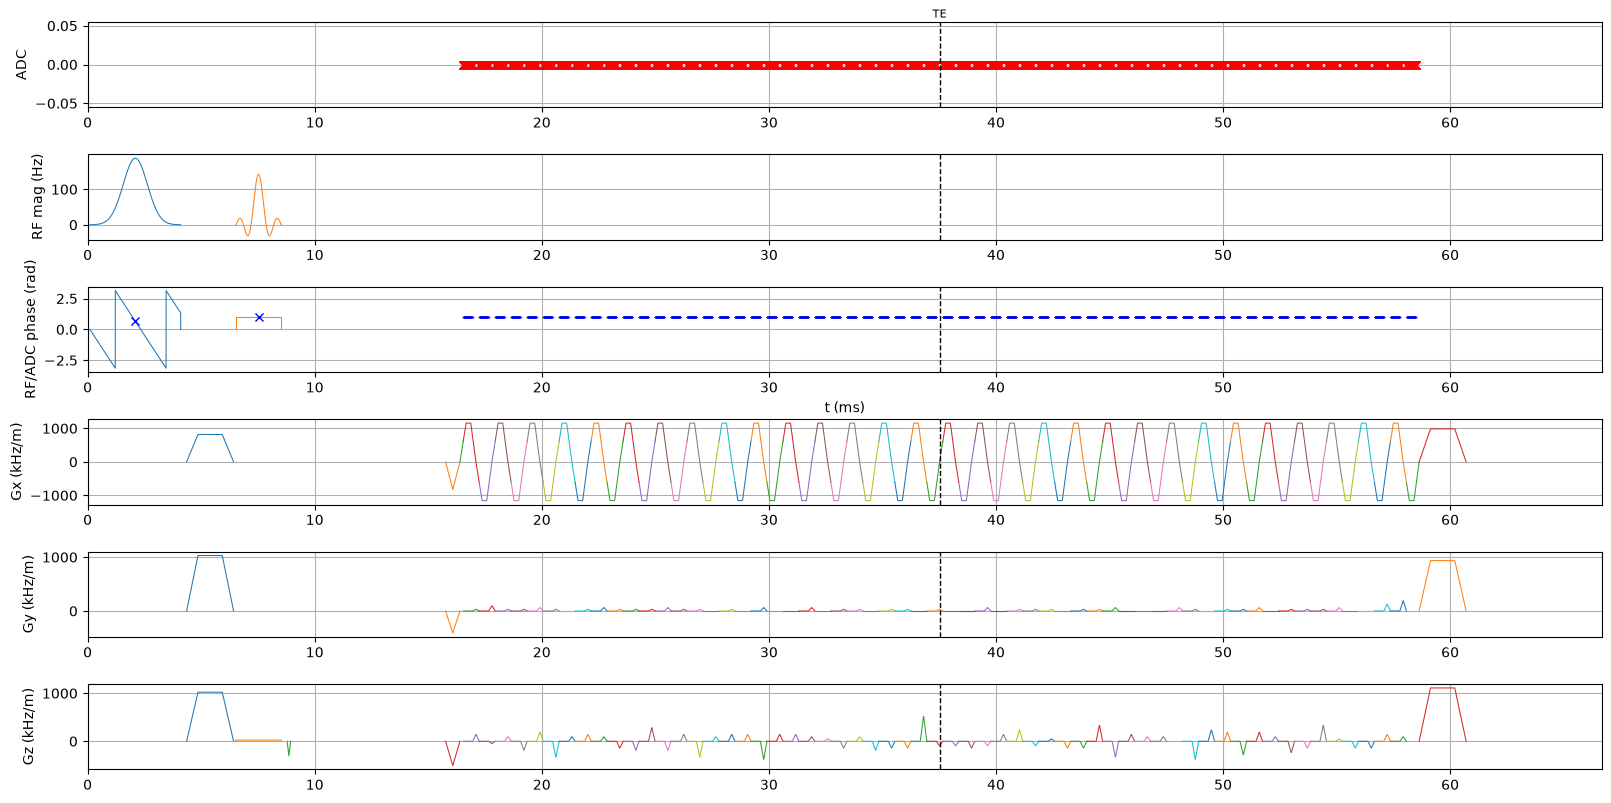

In [7]:
for p, s in [(params, seq), (params_other, seq_other)]:
    print(f"epi_trajectory = '{p.epi_trajectory}'")
    show(plot_one_tr(s, p, shot_index=0), width=16)

### PNS over one TR

Gradients, slew rate and predicted peripheral nerve stimulation (GE's IEC
60601-2-33:2022 model, `ge/pns.py`) for the same shot of the default-trajectory
sequence. The horizontal lines are the 80% (normal mode) and 100% (first controlled
mode) limits; `main.py --ge` warns between them and refuses to export above 100%.

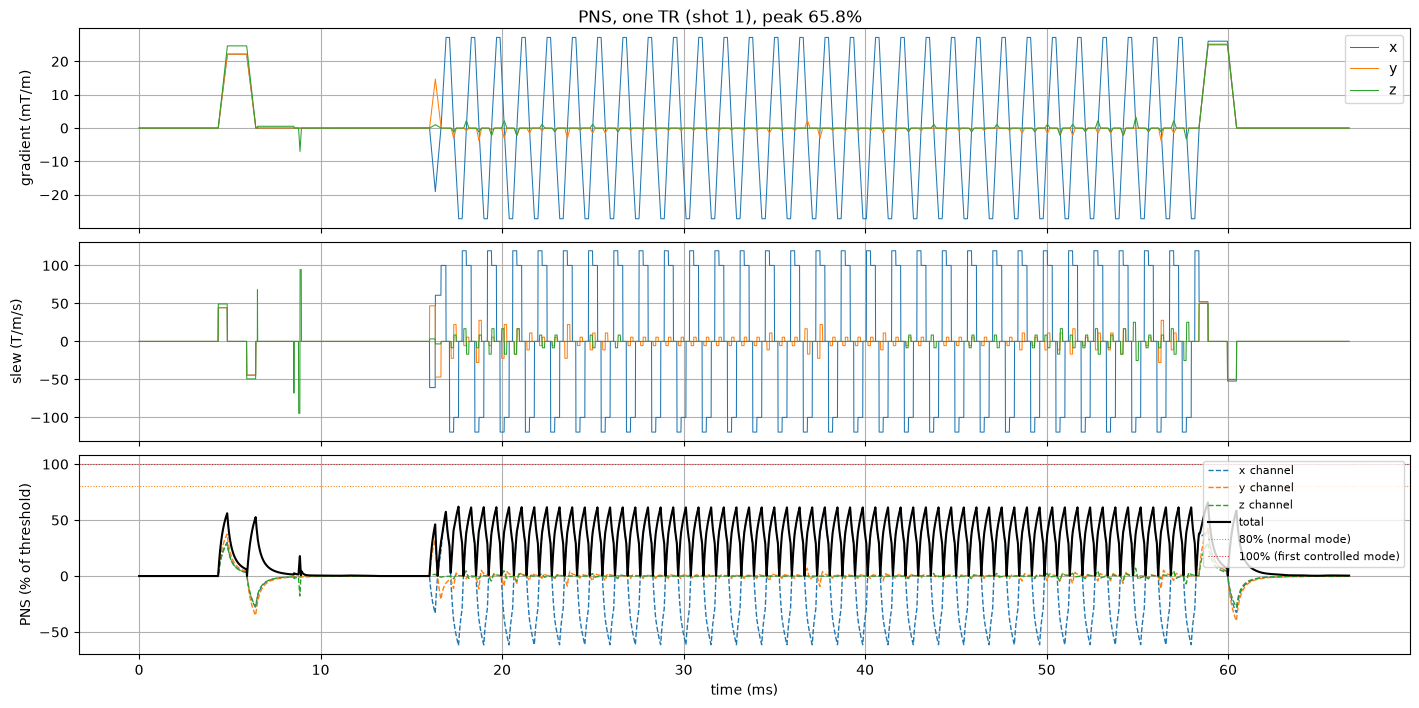

In [8]:
show(plot_pns_one_tr(seq, params, shot_index=0), width=14)

## 4. Calibration, noise and deGRE sequences

- `EPIcal`: the same readout with every blip off, for odd/even (Nyquist ghost)
  phase correction.
- `noise`: a noise prescan (no RF, no gradients), for coil noise covariance.
- `deGRE`: a dual-echo GRE, for coil sensitivity maps and the B0 field map.

`generate_epical` and `generate_noise` read `scan_info.mat`, so they run after
`generate_arbepi`; `generate_degre` runs last so that it can write its realized echo
times into that file.

In [9]:
seqs = {"ArbEPI": seq}
seqs["EPIcal"] = generate_epical(params)
seqs["noise"] = generate_noise(params)
seqs["deGRE"] = generate_degre(params)

for name, s in seqs.items():
    print(f"{name:>7}: {s.duration()[0]:7.2f} s  -> {params.output_dir}/{name}.seq")

Timing check passed successfully
Validating sequence...
  Timing check PASSED.

Sequence written to: output/noise.seq


Timing check passed successfully


 ArbEPI:   60.00 s  -> output/ArbEPI.seq
 EPIcal:    1.00 s  -> output/EPIcal.seq
  noise:    0.14 s  -> output/noise.seq
  deGRE:  140.04 s  -> output/deGRE.seq


## 5. GE feasibility check and export

What `main.py --ge` does: check every sequence against the scanner's gradient,
slew and B1 limits, PNS and acoustic resonances (`ge/check.py`) before writing any
`.pge` file. Set `EXPORT_GE = True` to also write the `.pge` files.

In [10]:
EXPORT_GE = False

checked = {}
for name in seqs:
    seq_path = os.path.join(params.output_dir, f"{name}.seq")
    checked[name] = check_ge_feasibility(seq_path, params)  # prints its report

if EXPORT_GE:
    for name, (s, report) in checked.items():
        export_to_ge(os.path.join(params.output_dir, f"{name}.seq"),
                     os.path.join(params.output_dir, name), params, seq=s, report=report)

ArbEPI.seq:
OK   max grad: 28.83 mT/m (limit 50.00)
OK   max slew: 119.2 T/m/s (limit 200.0)
OK   max B1: 0.0440 G (limit 0.2500)
OK   peak PNS: 69.4% (within normal mode)
OK   acoustics: 0.0231 (limit 0.3)
EPIcal.seq:
OK   max grad: 28.25 mT/m (limit 50.00)
OK   max slew: 119.2 T/m/s (limit 200.0)
OK   max B1: 0.0440 G (limit 0.2500)
OK   peak PNS: 65.1% (within normal mode)
OK   acoustics: 0.0231 (limit 0.3)
noise.seq:
OK   max grad: 0.00 mT/m (limit 50.00)
OK   max slew: 0.0 T/m/s (limit 200.0)
OK   max B1: 0.0334 G (limit 0.2500)
OK   peak PNS: 0.0% (within normal mode)
OK   acoustics: 0.0000 (limit 0.3)


deGRE.seq:
OK   max grad: 49.76 mT/m (limit 50.00)
OK   max slew: 174.3 T/m/s (limit 200.0)
OK   max B1: 0.0583 G (limit 0.2500)
OK   peak PNS: 77.4% (within normal mode)
OK   acoustics: 0.2556 (limit 0.3)
